In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score

In [ ]:
# Generate X - Random input features of 100 records with 1 feature - Shape (100, 1)
X = 6 * np.random.rand(100, 1) - 3
# Generate y - Quadratic equation - ax^2 + bx + c - Shape (100, 1)
y = 0.5 * X**2 + 2 + X + np.random.randn(100, 1)

plt.scatter(X, y, color="green")
plt.xlabel("x Feature")
plt.ylabel("y Feature")

### In this section, let's apply simple linear regression to model the non-linear relationship in our dataset.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression(n_jobs=-1)
model.fit(X_train, y_train)

plt.scatter(X_train, y_train, color="green")
plt.plot(X_train, model.predict(X_train), color="blue")

In [ ]:
mse = mean_squared_error(y_test, model.predict(X_test))
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, model.predict(X_test))

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)

In [ ]:
r2_squared = r2_score(y_test, model.predict(X_test))

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2_squared) * (n - 1) / (n - p - 1)

print("R-squared (R²):", r2_squared)
print("Adjusted R-squared:", adjusted_r2)

### Now, let's apply Polynomial Regression to model the non-linear relationship in our dataset.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=True)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression(n_jobs=-1)
model.fit(X_train_poly, y_train)

r2_score(y_test, model.predict(X_test_poly))

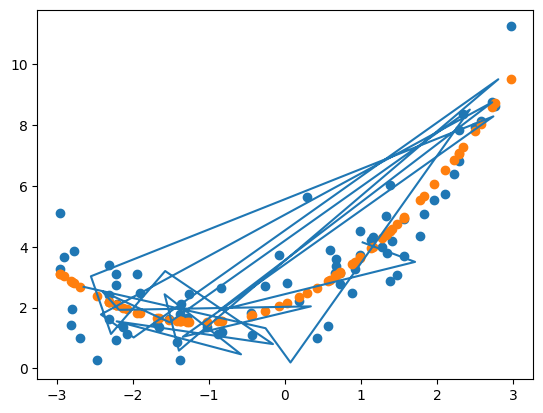

In [89]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, model.predict(X_train_poly))
plt.plot(X_test, y_test)